<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/LN_MLP_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. IMPORT LIBRARIES

In [13]:
# ======================================================
# 1. IMPORT LIBRARIES
# ======================================================

# ==============================
# Data Processing
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Data Visualization
# ==============================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ==============================
# Machine Learning Utilities
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# Evaluation Metrics
# ==============================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==============================
# Warning Configuration
# ==============================
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. LOAD DATA

In [14]:
# ======================================================
# 2. LOAD DATA
# ======================================================

# ==============================
# Random Seed
# ==============================
np.random.seed(42)

# ==============================
# Dataset URL
# ==============================
url = "https://raw.githubusercontent.com/hoangchaulanbao/HocmayNC/main/car_sales_data.csv"

# ==============================
# Load Dataset
# ==============================
df = pd.read_csv(url)

print("Dataset loaded successfully.")

# ==============================
# Dataset Shape
# ==============================
rows, cols = df.shape

print(f"Number of rows    : {rows}")
print(f"Number of columns : {cols}")

# ==============================
# Preview Dataset
# ==============================
display(df.head())

# ==============================
# Data Types
# ==============================
print("\nDataset Information:")
print(df.dtypes)

Dataset loaded successfully.
Number of rows    : 50000
Number of columns : 7


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101



Dataset Information:
Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object


# 3. EXPLORATORY DATA ANALYSIS (EDA)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB

========== DESCRIPTIVE STATISTICS ==========


,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000



========== MISSING VALUES ==========


,0
Manufacturer,0
Model,0
Engine size,0
Fuel type,0
Year of manufacture,0
Mileage,0
Price,0



Total missing values: 0

========== DUPLICATED ROWS ==========
Number of duplicated rows: 12
Dataset shape after removing duplicates: (49988, 7)

========== INVALID VALUE CHECK ==========
Column 'Engine size' does not contain negative values.
Column 'Year of manufacture' does not contain negative values.
Column 'Mileage' does not contain negative values.
Column 'Price' does not contain negative values.

========== ENGINE SIZE VALIDATION ==========
Engine size values are within a reasonable range.

========== YEAR VALIDATION ==========
Year values are within a valid range.

========== UNIQUE VALUES ==========


,0
Manufacturer,5
Model,15
Engine size,14
Fuel type,3
Year of manufacture,39
Mileage,44971
Price,25045



========== DATA TYPES ==========


,0
Manufacturer,object
Model,object
Engine size,float64
Fuel type,object
Year of manufacture,int64
Mileage,int64
Price,int64


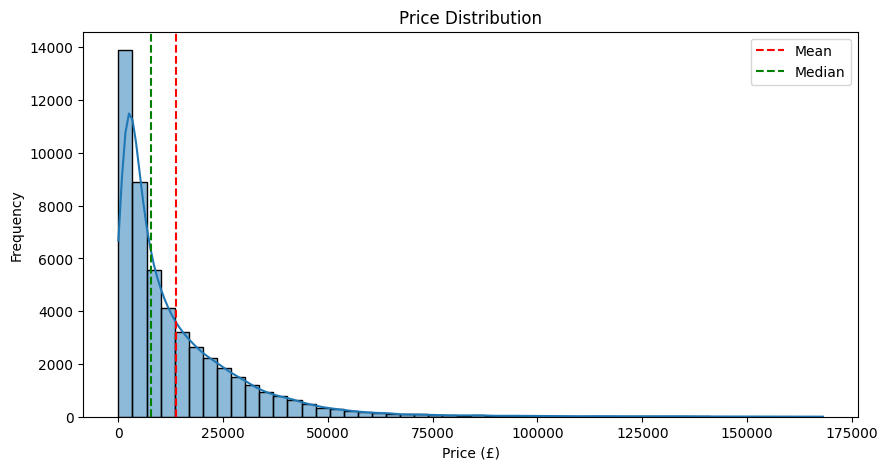


GIẢI THÍCH:
- Phân bố giá hơi lệch về bên phải.

- Hầu hết các xe tập trung ở phân khúc giá thấp đến trung bình.

- Một số ít xe đắt tiền tạo thành các giá trị ngoại lệ.



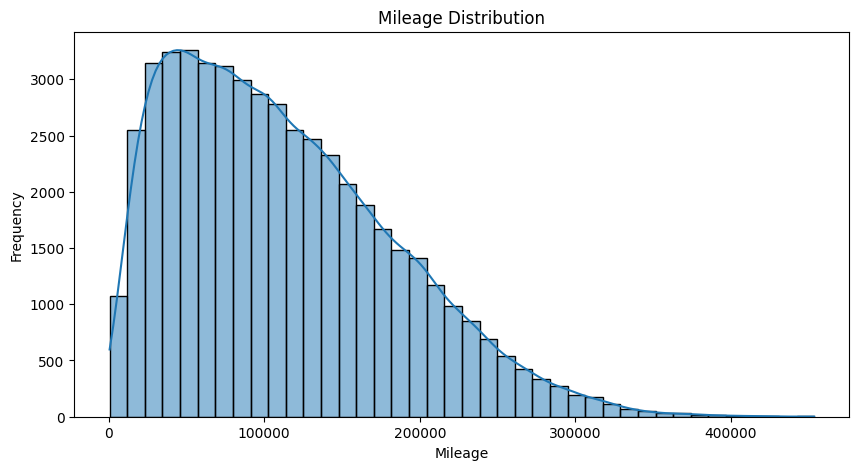


- Phân bố quãng đường đi được bị lệch phải.

- Hầu hết các xe đều có quãng đường đi được tương đối thấp.

- Phép biến đổi logarit có thể giúp chuẩn hóa phân bố.



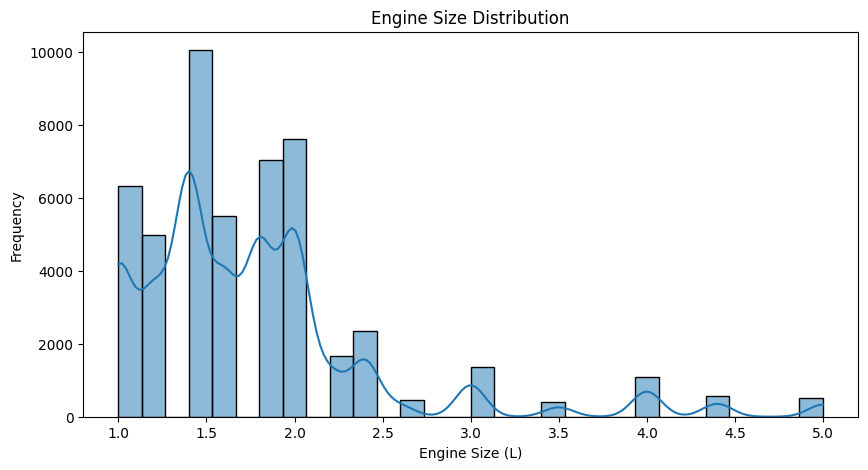


- Hầu hết các loại xe đều có động cơ cỡ nhỏ đến trung bình.

- Xe có động cơ lớn tương đối hiếm.



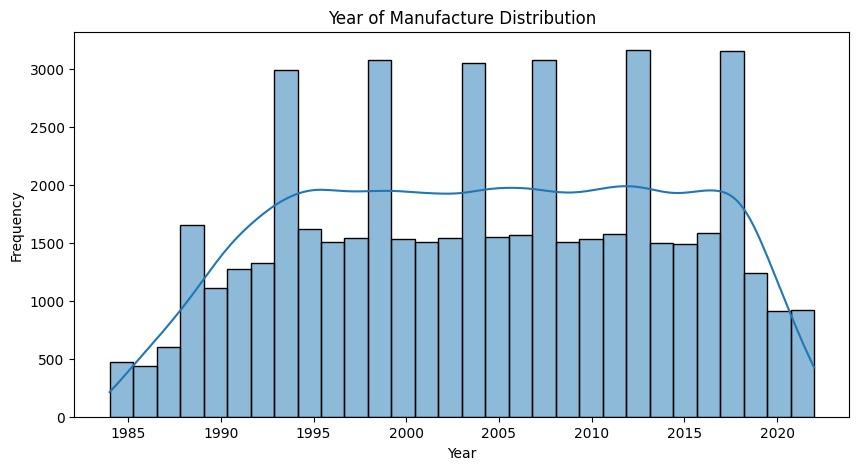


GIẢI THÍCH:
- Hầu hết các phương tiện được sản xuất trong những năm gần đây.

- Các phương tiện đời mới chiếm ưu thế trong tập dữ liệu.



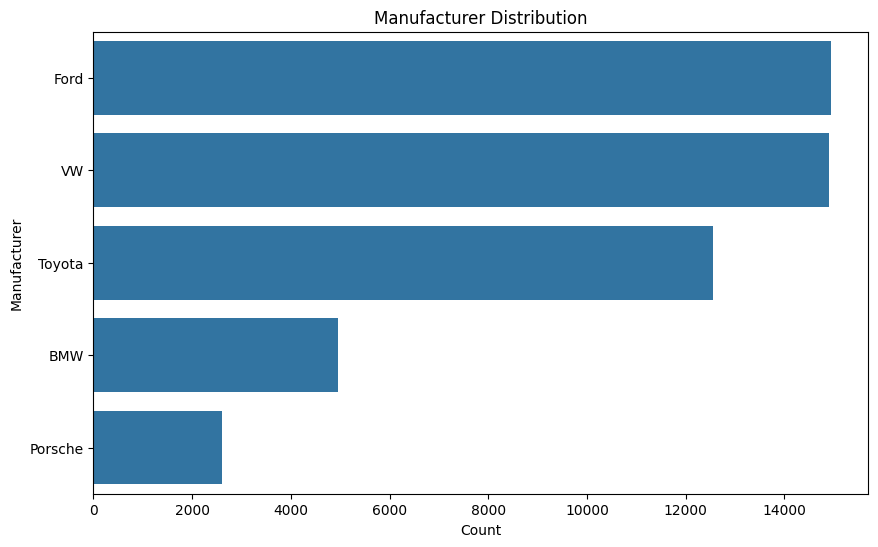

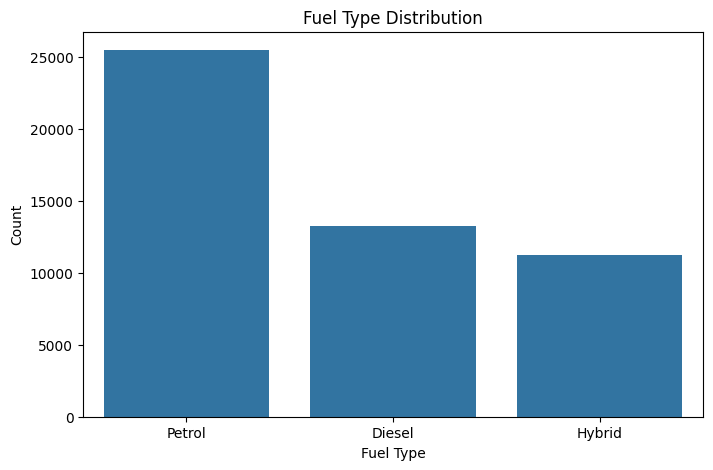

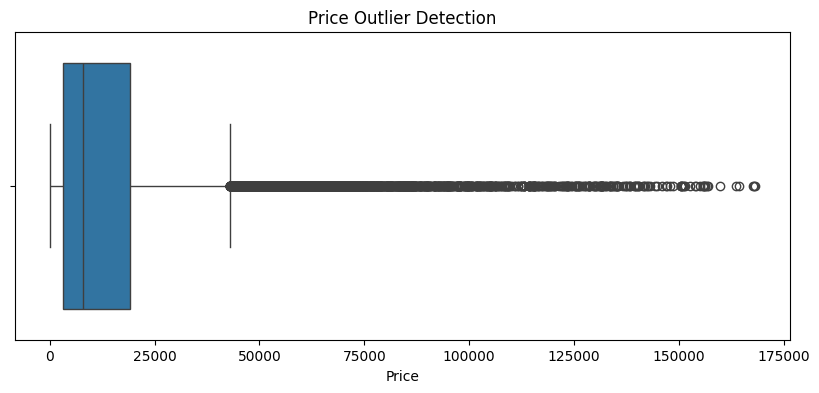

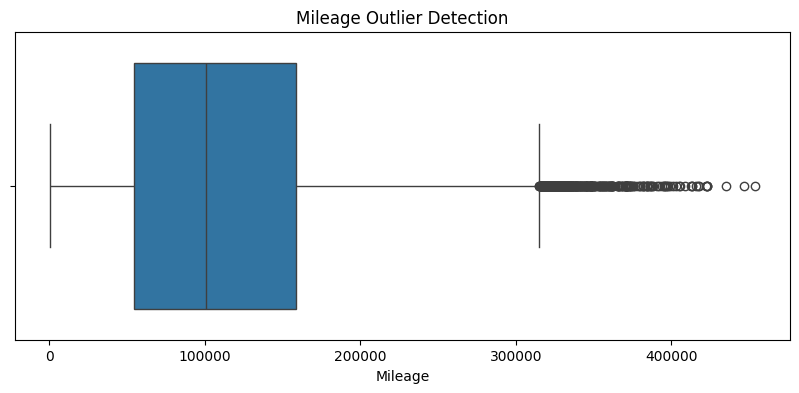


GIẢI THÍCH:
- Có các giá trị ngoại lệ trong các đặc điểm Giá cả và Số dặm đã đi.

- Hồi quy tuyến tính nhạy cảm với các giá trị cực đoan.

- Tuy nhiên, các quan sát này được giữ lại để bảo toàn hành vi thị trường thực tế.



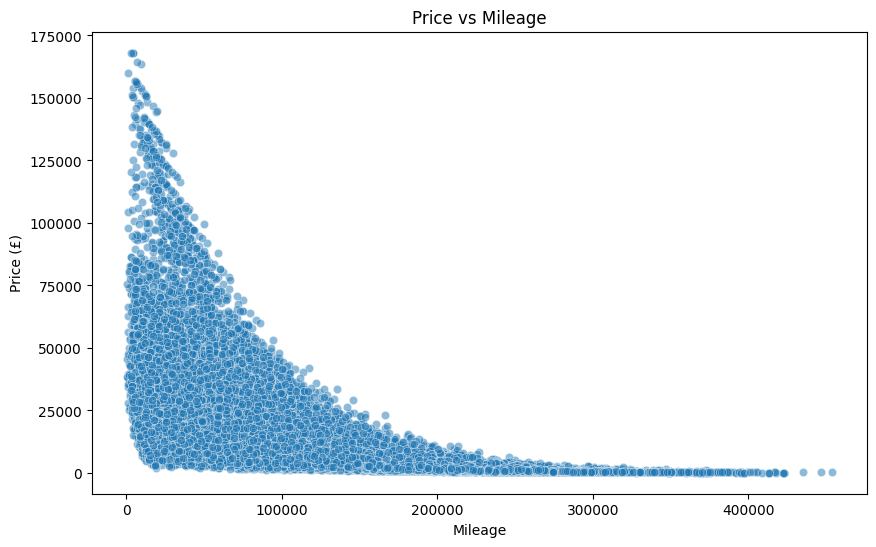


Số km đã đi có mối quan hệ nghịch với giá cả.

- Xe có số km đã đi cao hơn thường có giá thấp hơn.



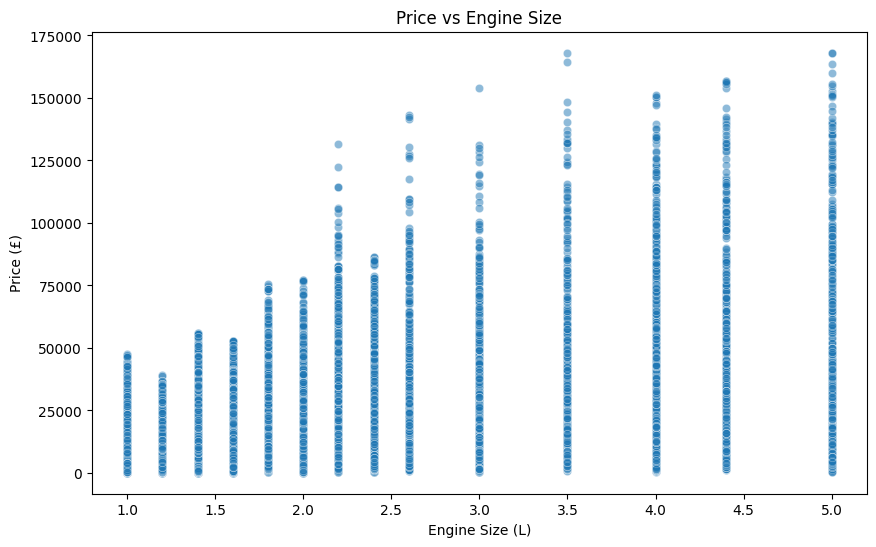


- Dung tích động cơ có mối quan hệ thuận với giá cả.

- Xe có động cơ lớn hơn thường có giá cao hơn.



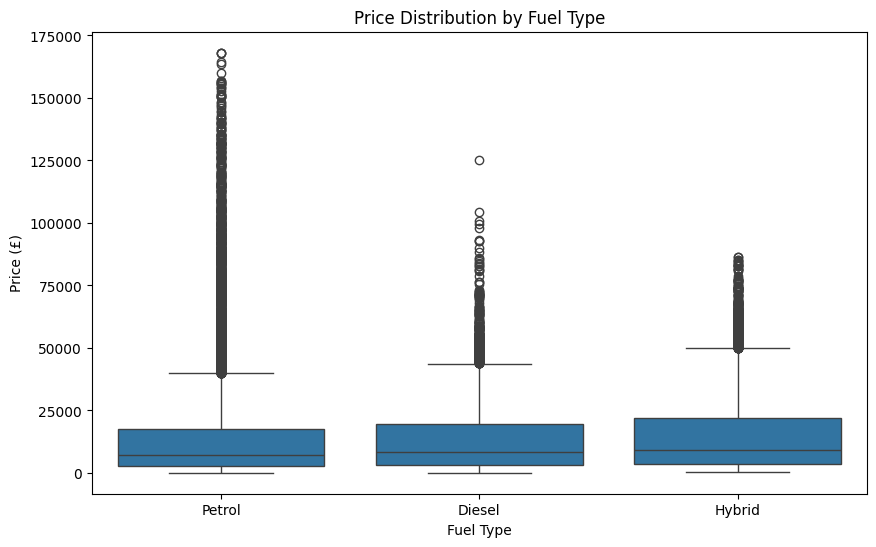

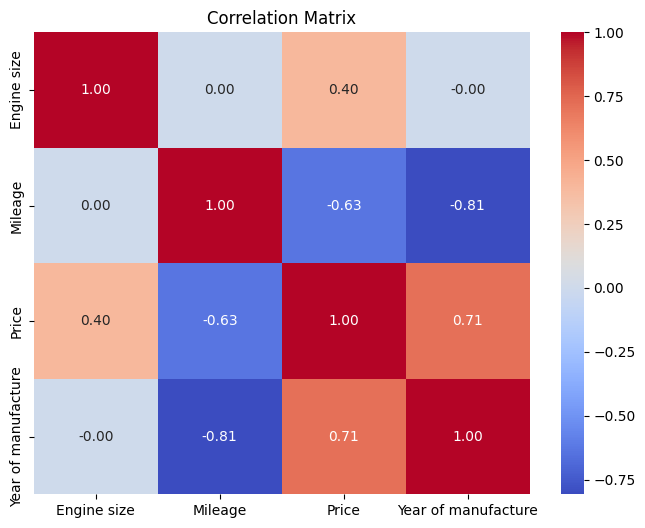


GIẢI THÍCH:
- Dung tích động cơ tỷ lệ thuận với giá cả.

- Số km đã đi tỷ lệ nghịch với giá cả.

- Xe đời mới thường có giá cao hơn.


========== TARGET VARIABLE ==========
Target variable: Price

========== FEATURE COLUMNS ==========
1. Manufacturer
2. Model
3. Engine size
4. Fuel type
5. Year of manufacture
6. Mileage

Total number of features: 6

KEY FINDINGS FROM EDA

1. Phân bố giá lệch phải.

2. Số dặm đi được có mối quan hệ nghịch với giá cả.

3. Dung tích động cơ tương quan thuận với giá cả.

4. Xe đời mới thường có giá cao hơn.

5. Số dặm đi được có phân bố lệch và có thể cần biến đổi logarit.

6. Có một số giá trị ngoại lệ trong giá cả và số dặm đi được.

7. Chất lượng dữ liệu nhìn chung tốt, không có vấn đề thiếu dữ liệu nghiêm trọng.



In [15]:
# ======================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ======================================================

# ======================================================
# 3.1 DATA INSPECTION
# ======================================================

# ==============================
# Dataset Information
# ==============================
print("========== DATASET INFO ==========")
df.info()

# ==============================
# Statistical Summary
# ==============================
print("\n========== DESCRIPTIVE STATISTICS ==========")
display(df.describe())

# ==============================
# Check Missing Values
# ==============================
print("\n========== MISSING VALUES ==========")

null_counts = df.isnull().sum()

display(null_counts)

print(f"\nTotal missing values: {null_counts.sum()}")

# ==============================
# Check Duplicate Rows
# ==============================
print("\n========== DUPLICATED ROWS ==========")

duplicate_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count}")

# Remove duplicates
df.drop_duplicates(inplace=True)

print(f"Dataset shape after removing duplicates: {df.shape}")

# ==============================
# Check Invalid Numerical Values
# ==============================
print("\n========== INVALID VALUE CHECK ==========")

for col in df.select_dtypes(include=np.number).columns:

    if (df[col] < 0).any():
        print(f"Column '{col}' contains negative values.")
    else:
        print(f"Column '{col}' does not contain negative values.")

# ======================================================
# 3.2 DOMAIN VALIDATION
# ======================================================

# ==============================
# Engine Size Validation
# ==============================
print("\n========== ENGINE SIZE VALIDATION ==========")

zero_engine_size = df[df['Engine size'] == 0].shape[0]
large_engine_size = df[df['Engine size'] > 6.0].shape[0]

if zero_engine_size > 0:
    print(f"There are {zero_engine_size} vehicles with engine size = 0.")

if large_engine_size > 0:
    print(f"There are {large_engine_size} vehicles with engine size > 6.0L.")

if zero_engine_size == 0 and large_engine_size == 0:
    print("Engine size values are within a reasonable range.")

# ==============================
# Year of Manufacture Validation
# ==============================
print("\n========== YEAR VALIDATION ==========")

current_year = 2026

old_year = df[df['Year of manufacture'] < 1980].shape[0]
future_year = df[df['Year of manufacture'] > current_year].shape[0]

if old_year > 0:
    print(f"There are {old_year} vehicles manufactured before 1980.")

if future_year > 0:
    print(f"There are {future_year} vehicles manufactured after {current_year}.")

if old_year == 0 and future_year == 0:
    print("Year values are within a valid range.")

# ======================================================
# 3.3 UNIVARIATE ANALYSIS
# ======================================================

# ==============================
# Number of Unique Values
# ==============================
print("\n========== UNIQUE VALUES ==========")

display(df.nunique())

# ==============================
# Data Types
# ==============================
print("\n========== DATA TYPES ==========")

display(df.dtypes)

# ======================================================
# 3.3.1 Price Distribution
# ======================================================

plt.figure(figsize=(10,5))

sns.histplot(df['Price'], bins=50, kde=True)

plt.axvline(
    df['Price'].mean(),
    color='red',
    linestyle='--',
    label='Mean'
)

plt.axvline(
    df['Price'].median(),
    color='green',
    linestyle='--',
    label='Median'
)

plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

print("""
GIẢI THÍCH:
- Phân bố giá hơi lệch về bên phải.

- Hầu hết các xe tập trung ở phân khúc giá thấp đến trung bình.

- Một số ít xe đắt tiền tạo thành các giá trị ngoại lệ.
""")

# ======================================================
# 3.3.2 Mileage Distribution
# ======================================================

plt.figure(figsize=(10,5))

sns.histplot(df['Mileage'], bins=40, kde=True)

plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.ylabel("Frequency")

plt.show()

print("""
- Phân bố quãng đường đi được bị lệch phải.

- Hầu hết các xe đều có quãng đường đi được tương đối thấp.

- Phép biến đổi logarit có thể giúp chuẩn hóa phân bố.
""")

# ======================================================
# 3.3.3 Engine Size Distribution
# ======================================================

plt.figure(figsize=(10,5))

sns.histplot(df['Engine size'], bins=30, kde=True)

plt.title("Engine Size Distribution")
plt.xlabel("Engine Size (L)")
plt.ylabel("Frequency")

plt.show()

print("""
- Hầu hết các loại xe đều có động cơ cỡ nhỏ đến trung bình.

- Xe có động cơ lớn tương đối hiếm.
""")

# ======================================================
# 3.3.4 Year of Manufacture Distribution
# ======================================================

plt.figure(figsize=(10,5))

sns.histplot(df['Year of manufacture'], bins=30, kde=True)

plt.title("Year of Manufacture Distribution")
plt.xlabel("Year")
plt.ylabel("Frequency")

plt.show()

print("""
GIẢI THÍCH:
- Hầu hết các phương tiện được sản xuất trong những năm gần đây.

- Các phương tiện đời mới chiếm ưu thế trong tập dữ liệu.
""")

# ======================================================
# 3.3.5 Manufacturer Distribution
# ======================================================

plt.figure(figsize=(10,6))

manufacturer_counts = df['Manufacturer'].value_counts()

sns.barplot(
    x=manufacturer_counts.values,
    y=manufacturer_counts.index
)

plt.title("Manufacturer Distribution")
plt.xlabel("Count")
plt.ylabel("Manufacturer")

plt.show()

# ======================================================
# 3.3.6 Fuel Type Distribution
# ======================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Fuel type'
)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

# ======================================================
# 3.4 OUTLIER ANALYSIS
# ======================================================

# ==============================
# Price Outlier Detection
# ==============================
plt.figure(figsize=(10,4))

sns.boxplot(x=df['Price'])

plt.title("Price Outlier Detection")

plt.show()

# ==============================
# Mileage Outlier Detection
# ==============================
plt.figure(figsize=(10,4))

sns.boxplot(x=df['Mileage'])

plt.title("Mileage Outlier Detection")

plt.show()

print("""
GIẢI THÍCH:
- Có các giá trị ngoại lệ trong các đặc điểm Giá cả và Số dặm đã đi.

- Hồi quy tuyến tính nhạy cảm với các giá trị cực đoan.

- Tuy nhiên, các quan sát này được giữ lại để bảo toàn hành vi thị trường thực tế.
""")

# ======================================================
# 3.5 BIVARIATE & MULTIVARIATE ANALYSIS
# ======================================================

# ======================================================
# 3.5.1 Price vs Mileage
# ======================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Mileage',
    y='Price',
    alpha=0.5
)

plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price (£)")

plt.show()

print("""
Số km đã đi có mối quan hệ nghịch với giá cả.

- Xe có số km đã đi cao hơn thường có giá thấp hơn.
""")

# ======================================================
# 3.5.2 Price vs Engine Size
# ======================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Engine size',
    y='Price',
    alpha=0.5
)

plt.title("Price vs Engine Size")
plt.xlabel("Engine Size (L)")
plt.ylabel("Price (£)")

plt.show()

print("""
- Dung tích động cơ có mối quan hệ thuận với giá cả.

- Xe có động cơ lớn hơn thường có giá cao hơn.
""")

# ======================================================
# 3.5.3 Price by Fuel Type
# ======================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Fuel type',
    y='Price'
)

plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (£)")

plt.show()

# ======================================================
# 3.5.4 Correlation Matrix
# ======================================================

corr = df[
    ['Engine size', 'Mileage', 'Price', 'Year of manufacture']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

print("""
GIẢI THÍCH:
- Dung tích động cơ tỷ lệ thuận với giá cả.

- Số km đã đi tỷ lệ nghịch với giá cả.

- Xe đời mới thường có giá cao hơn.
""")

# ======================================================
# 3.6 TARGET VARIABLE & FEATURES
# ======================================================

# Split features and target
X = df.drop('Price', axis=1)
y = df['Price']

print("\n========== TARGET VARIABLE ==========")
print(f"Target variable: {y.name}")

print("\n========== FEATURE COLUMNS ==========")

for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

print(f"\nTotal number of features: {X.shape[1]}")

# ======================================================
# 3.7 KEY FINDINGS FROM EDA
# ======================================================

print("""
==================================================
KEY FINDINGS FROM EDA
==================================================

1. Phân bố giá lệch phải.

2. Số dặm đi được có mối quan hệ nghịch với giá cả.

3. Dung tích động cơ tương quan thuận với giá cả.

4. Xe đời mới thường có giá cao hơn.

5. Số dặm đi được có phân bố lệch và có thể cần biến đổi logarit.

6. Có một số giá trị ngoại lệ trong giá cả và số dặm đi được.

7. Chất lượng dữ liệu nhìn chung tốt, không có vấn đề thiếu dữ liệu nghiêm trọng.
==================================================
""")

# 4. DATA SPLITTING & PREPROCESSING

4.1 Tách biến đầu vào và biến mục tiêu

4.2 Chia tập dữ liệu

4.3 Feature Engineering

- 4.3.1 Tạo biến CarAge
- 4.3.2 Log Transformation cho Mileage
- 4.3.3 One-Hot Encoding

4.4 Chuẩn hóa dữ liệu (Feature Scaling)

4.5 Đồng bộ dữ liệu sau Encoding

4.6 Kiểm tra Data Leakage

In [16]:
# ======================================================
# 4. DATA SPLITTING & PREPROCESSING
# ======================================================

# ======================================================
# 4.1 SPLIT FEATURES & TARGET
# ======================================================

# ==============================
# Define Features (X) and Target (y)
# ==============================
X = df.drop('Price', axis=1)
y = df['Price']

print("========== FEATURE & TARGET ==========")
print(f"Feature shape : {X.shape}")
print(f"Target shape  : {y.shape}")

# ======================================================
# 4.2 TRAIN / VALIDATION / TEST SPLIT
# ======================================================

# ==============================
# First Split: Train and Temporary Set
# 80% Train / 20% Temporary
# ==============================
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# ==============================
# Second Split: Validation and Test
# 10% Validation / 10% Test
# ==============================
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

# ==============================
# Dataset Summary
# ==============================
print("\n========== DATASET SPLIT ==========")

print(f"Training samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Testing samples    : {X_test.shape[0]}")
print(f"Total samples      : {X.shape[0]}")

# ======================================================
# 4.3 FEATURE ENGINEERING
# ======================================================

# ======================================================
# 4.3.1 Create CarAge Feature
# ======================================================

# ==============================
# Convert manufacture year to vehicle age
# ==============================
for dataset in [X_train, X_val, X_test]:

    dataset['CarAge'] = 2026 - dataset['Year of manufacture']

    dataset.drop(
        columns=['Year of manufacture'],
        inplace=True
    )

print("\n========== FEATURE ENGINEERING ==========")
print("Feature 'CarAge' created successfully.")

# ======================================================
# 4.3.2 Log Transformation for Mileage
# ======================================================

# ==============================
# Reduce skewness in Mileage
# ==============================
for dataset in [X_train, X_val, X_test]:

    dataset['Mileage'] = np.log1p(dataset['Mileage'])

print("Log transformation applied to Mileage.")

# ======================================================
# 4.3.3 One-Hot Encoding
# ======================================================

# ==============================
# Categorical columns
# ==============================
categorical_cols = [
    'Manufacturer',
    'Fuel type',
    'Model'
]

# ==============================
# Apply One-Hot Encoding
# ==============================
X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_val = pd.get_dummies(
    X_val,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

# ==============================
# Align Columns
# Avoid feature mismatch
# ==============================
X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("One-hot encoding completed successfully.")

# ======================================================
# 4.4 FEATURE SCALING
# ======================================================

# ==============================
# Initialize StandardScaler
# ==============================
scaler = StandardScaler()

# ==============================
# Numerical columns
# ==============================
numerical_cols = [
    'Mileage',
    'CarAge',
    'Engine size'
]

# ==============================
# Fit scaler only on training set
# ==============================
X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

# ==============================
# Transform validation and test sets
# ==============================
X_val[numerical_cols] = scaler.transform(
    X_val[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("Feature scaling completed successfully.")

# ======================================================
# 4.5 PREPROCESSED DATA SUMMARY
# ======================================================

print("\n========== FINAL DATA SHAPES ==========")

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")

print(f"\nNumber of final features : {X_train.shape[1]}")

# ======================================================
# 4.6 CHECK FOR DATA LEAKAGE
# ======================================================

print("\n========== DATA LEAKAGE CHECK ==========")

print("""
1. Train/Validation/Test split completed before scaling.
2. StandardScaler fitted only on training data.
3. Validation and test data transformed using trained scaler.
4. No target leakage detected.
""")

# ======================================================
# 4.7 PREPROCESSING INTERPRETATION
# ======================================================

print("""
==================================================
PREPROCESSING INTERPRETATION
==================================================
1. Tập dữ liệu được chia thành tập huấn luyện, tập xác thực,

và tập kiểm tra để đảm bảo đánh giá không thiên vị.

2. Biến CarAge được tạo ra từ Năm sản xuất

để thể hiện tốt hơn sự khấu hao của xe.

3. Biến đổi logarit được áp dụng cho Mileage

để giảm độ lệch và cải thiện tính ổn định của mô hình.

4. Mã hóa one-hot chuyển đổi các biến phân loại

thành định dạng số phù hợp cho Hồi quy tuyến tính.

5. Chuẩn hóa được áp dụng cho các đặc trưng số

để cải thiện tốc độ hội tụ của thuật toán Gradient Descent.

==================================================
""")

========== FEATURE & TARGET ==========
Feature shape : (49988, 6)
Target shape  : (49988,)

========== DATASET SPLIT ==========
Training samples   : 39990
Validation samples : 4999
Testing samples    : 4999
Total samples      : 49988

========== FEATURE ENGINEERING ==========
Feature 'CarAge' created successfully.
Log transformation applied to Mileage.
One-hot encoding completed successfully.
Feature scaling completed successfully.

========== FINAL DATA SHAPES ==========
X_train shape : (39990, 23)
X_val shape   : (4999, 23)
X_test shape  : (4999, 23)

Number of final features : 23

========== DATA LEAKAGE CHECK ==========

1. Train/Validation/Test split completed before scaling.
2. StandardScaler fitted only on training data.
3. Validation and test data transformed using trained scaler.
4. No target leakage detected.


PREPROCESSING INTERPRETATION
1. Tập dữ liệu được chia thành tập huấn luyện, tập xác thực,

và tập kiểm tra để đảm bảo đánh giá không thiên vị.

2. Biến CarAge được tạo

# 5. BUILD LINEAR REGRESSION MODEL


5.1	Chuẩn bị dữ liệu NumPy

5.2	Thêm bias term

5.3	Khởi tạo theta

5.4	Xây dựng hàm loss (MSE)

5.5	Xây dựng Gradient Descent

In [17]:
# ======================================================
# 5. BUILD LINEAR REGRESSION MODEL
# ======================================================

# ======================================================
# 5.1 HYPERPARAMETERS
# ======================================================

# ==============================
# Learning Configuration
# ==============================
LEARNING_RATE = 0.01

EPOCHS_200 = 200
EPOCHS_1000 = 1000

# ==============================
# Batch Size
# Batch Gradient Descent uses
# the entire training dataset
# ==============================
BATCH_SIZE = X_train.shape[0]

print("========== HYPERPARAMETERS ==========")

print(f"Learning Rate : {LEARNING_RATE}")
print(f"Epochs (200)  : {EPOCHS_200}")
print(f"Epochs (1000) : {EPOCHS_1000}")
print(f"Batch Size    : {BATCH_SIZE}")

# ======================================================
# 5.2 CONVERT DATA TO NUMPY
# ======================================================

# ==============================
# Convert feature matrices
# ==============================
X_train_np = X_train.values
X_val_np = X_val.values
X_test_np = X_test.values

# ==============================
# Convert target vectors
# ==============================
y_train_np = y_train.values.reshape(-1, 1)
y_val_np = y_val.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

print("\n========== NUMPY CONVERSION ==========")

print(f"X_train shape : {X_train_np.shape}")
print(f"X_val shape   : {X_val_np.shape}")
print(f"X_test shape  : {X_test_np.shape}")

# ======================================================
# 5.3 ADD BIAS TERM
# ======================================================

# ==============================
# Add x0 = 1 for intercept term
# ==============================
X_train_b = np.c_[
    np.ones((X_train_np.shape[0], 1)),
    X_train_np
]

X_val_b = np.c_[
    np.ones((X_val_np.shape[0], 1)),
    X_val_np
]

X_test_b = np.c_[
    np.ones((X_test_np.shape[0], 1)),
    X_test_np
]

print("\n========== BIAS TERM ADDED ==========")

print(f"Train shape : {X_train_b.shape}")
print(f"Val shape   : {X_val_b.shape}")
print(f"Test shape  : {X_test_b.shape}")

# ======================================================
# 5.4 INITIALIZE PARAMETERS (THETA)
# ======================================================

# ==============================
# Number of features
# ==============================
n_features = X_train_b.shape[1]

# ==============================
# Initialize theta with zeros
# ==============================
theta_init = np.zeros((n_features, 1))

print("\n========== THETA INITIALIZATION ==========")

print(f"Theta shape : {theta_init.shape}")

# ======================================================
# 5.5 DEFINE LOSS FUNCTION (MSE)
# ======================================================

# ==============================
# Mean Squared Error Loss
# ==============================
def compute_loss(X, y, theta):

    m = len(y)

    predictions = X @ theta

    loss = (1 / (2 * m)) * np.sum((predictions - y) ** 2)

    return loss

print("\nLoss function created successfully.")

# ======================================================
# 5.6 DEFINE GRADIENT DESCENT
# ======================================================

def gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    learning_rate,
    epochs
):

    # ==============================
    # Number of training samples
    # ==============================
    m_train = len(y_train)

    # ==============================
    # Store loss history
    # ==============================
    train_loss_history = []
    val_loss_history = []

    # ==============================
    # Training loop
    # ==============================
    for epoch in range(epochs):

        # ==============================
        # Forward propagation
        # ==============================
        predictions = X_train @ theta

        # ==============================
        # Compute gradients
        # ==============================
        gradients = (
            1 / m_train
        ) * (X_train.T @ (predictions - y_train))

        # ==============================
        # Update parameters
        # ==============================
        theta = theta - learning_rate * gradients

        # ==============================
        # Compute train loss
        # ==============================
        train_loss = compute_loss(
            X_train,
            y_train,
            theta
        )

        train_loss_history.append(train_loss)

        # ==============================
        # Compute validation loss
        # ==============================
        val_loss = compute_loss(
            X_val,
            y_val,
            theta
        )

        val_loss_history.append(val_loss)

    # ==============================
    # Return results
    # ==============================
    return theta, train_loss_history, val_loss_history

print("Gradient Descent function created successfully.")

# ======================================================
# 5.7 MODEL INTERPRETATION
# ======================================================

print("""
==================================================
LINEAR REGRESSION MODEL INTERPRETATION
==================================================

1. Mô hình sử dụng thuật toán tối ưu hóa Batch Gradient Descent


2. Sai số bình phương trung bình (MSE) được sử dụng
làm hàm mất mát.

3. Tốc độ học (Learning Rate) kiểm soát kích thước bước
trong quá trình cập nhật tham số.

4. Số epoch xác định số lần
lặp lại trên tập dữ liệu huấn luyện.

5. Việc chuẩn hóa đặc trưng (Feature scaling) được áp dụng để cải thiện
sự ổn định hội tụ của Gradient Descent.

==================================================
""")

========== HYPERPARAMETERS ==========
Learning Rate : 0.01
Epochs (200)  : 200
Epochs (1000) : 1000
Batch Size    : 39990

========== NUMPY CONVERSION ==========
X_train shape : (39990, 23)
X_val shape   : (4999, 23)
X_test shape  : (4999, 23)

========== BIAS TERM ADDED ==========
Train shape : (39990, 24)
Val shape   : (4999, 24)
Test shape  : (4999, 24)

========== THETA INITIALIZATION ==========
Theta shape : (24, 1)

Loss function created successfully.
Gradient Descent function created successfully.

LINEAR REGRESSION MODEL INTERPRETATION

1. Mô hình sử dụng thuật toán tối ưu hóa Batch Gradient Descent


2. Sai số bình phương trung bình (MSE) được sử dụng
làm hàm mất mát.

3. Tốc độ học (Learning Rate) kiểm soát kích thước bước
trong quá trình cập nhật tham số.

4. Số epoch xác định số lần
lặp lại trên tập dữ liệu huấn luyện.

5. Việc chuẩn hóa đặc trưng (Feature scaling) được áp dụng để cải thiện
sự ổn định hội tụ của Gradient Descent.




# 6. TRAIN MODEL + LOSS CURVE ANALYSIS
Train model với 200 epochs

6.2	Vẽ Loss Curve

6.3	Actual vs Predicted

6.4	Train lại với 1000 epochs

6.5	So sánh convergence

6.6	Overfitting / Underfitting analysis

========== TRAINING MODEL (200 EPOCHS) ==========
Training completed successfully.


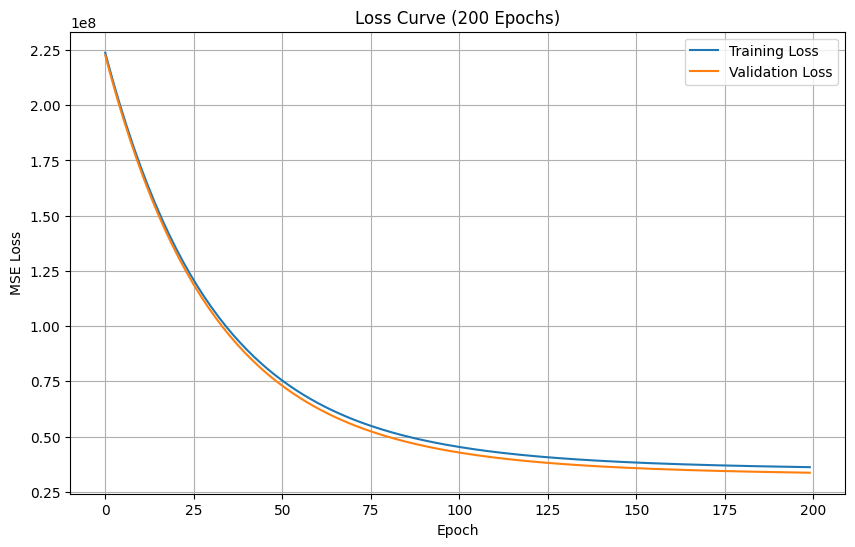


INTERPRETATION:
- Training loss decreases gradually over epochs.
- Validation loss follows a similar trend.
- The model shows stable convergence behavior.



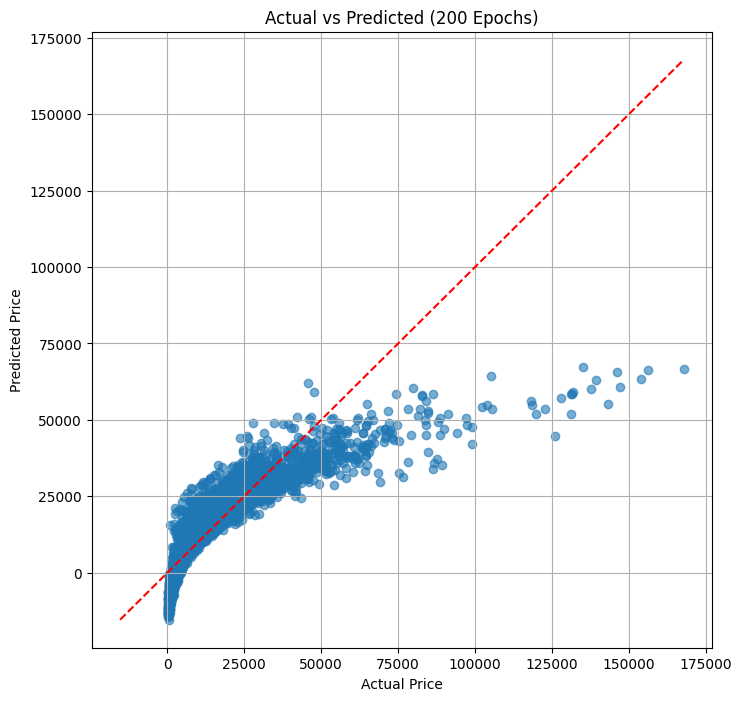


GIẢI THÍCH:
- Các dự đoán càng gần đường chéo màu đỏ

cho thấy hiệu suất mô hình càng tốt.

- Vẫn còn một số lỗi dự đoán do
giả định tuyến tính của mô hình.


========== TRAINING MODEL (1000 EPOCHS) ==========
Training completed successfully.


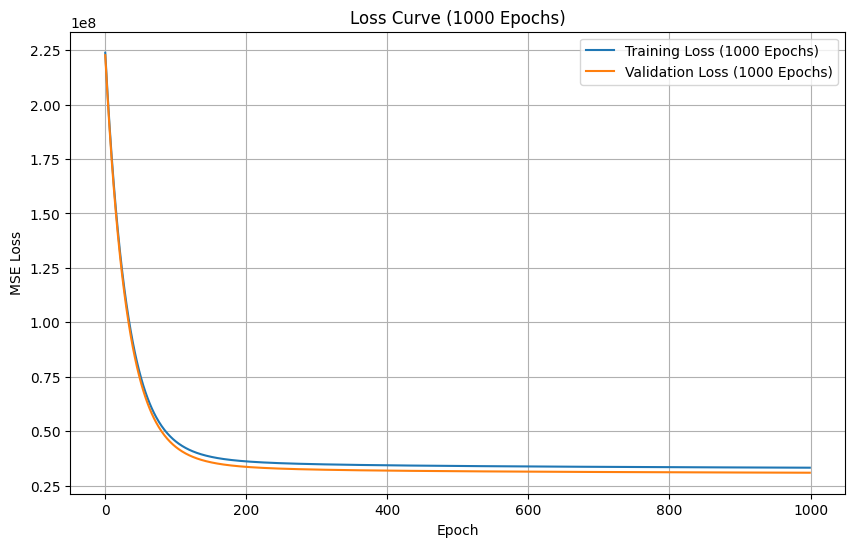


INTERPRETATION:
- Cả training and validation losses đều giảm
đáng kể trong các epoch đầu tiên.

- The loss curves sau khi huấn luyện đủ thời gian,

cho thấy sự hội tụ của thuật toán Gradient Descent.

- Không bi overfitting if validation loss
  remains close to training loss.


OVERFITTING / UNDERFITTING ANALYSIS

1. If training loss is low and validation loss
   is also low:
   -> Good generalization.

2. If training loss is low but validation loss
   becomes high:
   -> Overfitting.

3. If both losses remain high:
   -> Underfitting.

4. In this study, the model demonstrates
   relatively stable convergence behavior.




In [18]:
# ======================================================
# 6. TRAIN MODEL & LOSS CURVE ANALYSIS
# ======================================================

# ======================================================
# 6.1 TRAIN MODEL WITH 200 EPOCHS
# ======================================================

print("========== TRAINING MODEL (200 EPOCHS) ==========")

# ==============================
# Reset theta before training
# ==============================
theta_200_init = np.zeros((n_features, 1))

# ==============================
# Train model
# ==============================
theta_200, train_loss_200, val_loss_200 = gradient_descent(
    X_train_b,
    y_train_np,
    X_val_b,
    y_val_np,
    theta_200_init,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS_200
)

print("Training completed successfully.")

# ======================================================
# 6.2 VISUALIZE LOSS CURVE (200 EPOCHS)
# ======================================================

plt.figure(figsize=(10,6))

plt.plot(
    train_loss_200,
    label='Training Loss'
)

plt.plot(
    val_loss_200,
    label='Validation Loss'
)

plt.title("Loss Curve (200 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.grid(True)

plt.show()

print("""
INTERPRETATION:
- Training loss decreases gradually over epochs.
- Validation loss follows a similar trend.
- The model shows stable convergence behavior.
""")

# ======================================================
# 6.3 ACTUAL VS PREDICTED (200 EPOCHS)
# ======================================================

# ==============================
# Predict on test set
# ==============================
y_pred_200 = X_test_b @ theta_200

# ==============================
# Visualization
# ==============================
plt.figure(figsize=(8,8))

plt.scatter(
    y_test_np,
    y_pred_200,
    alpha=0.6
)

# Ideal prediction line
min_val = min(y_test_np.min(), y_pred_200.min())
max_val = max(y_test_np.max(), y_pred_200.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted (200 Epochs)")

plt.grid(True)

plt.show()

print("""
GIẢI THÍCH:
- Các dự đoán càng gần đường chéo màu đỏ

cho thấy hiệu suất mô hình càng tốt.

- Vẫn còn một số lỗi dự đoán do
giả định tuyến tính của mô hình.
""")

# ======================================================
# 6.4 TRAIN MODEL WITH 1000 EPOCHS
# ======================================================

print("\n========== TRAINING MODEL (1000 EPOCHS) ==========")

# ==============================
# Reset theta before training
# ==============================
theta_1000_init = np.zeros((n_features, 1))

# ==============================
# Train model
# ==============================
theta_1000, train_loss_1000, val_loss_1000 = gradient_descent(
    X_train_b,
    y_train_np,
    X_val_b,
    y_val_np,
    theta_1000_init,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS_1000
)

print("Training completed successfully.")

# ======================================================
# 6.5 LOSS CURVE COMPARISON
# ======================================================

plt.figure(figsize=(10,6))

plt.plot(
    train_loss_1000,
    label='Training Loss (1000 Epochs)'
)

plt.plot(
    val_loss_1000,
    label='Validation Loss (1000 Epochs)'
)

plt.title("Loss Curve (1000 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.grid(True)

plt.show()

print("""
INTERPRETATION:
- Cả training and validation losses đều giảm
đáng kể trong các epoch đầu tiên.

- The loss curves sau khi huấn luyện đủ thời gian,

cho thấy sự hội tụ của thuật toán Gradient Descent.

- Không bi overfitting if validation loss
  remains close to training loss.
""")

# ======================================================
# 6.6 OVERFITTING / UNDERFITTING ANALYSIS
# ======================================================

print("""
==================================================
OVERFITTING / UNDERFITTING ANALYSIS
==================================================

1. If training loss is low and validation loss
   is also low:
   -> Good generalization.

2. If training loss is low but validation loss
   becomes high:
   -> Overfitting.

3. If both losses remain high:
   -> Underfitting.

4. In this study, the model demonstrates
   relatively stable convergence behavior.

==================================================
""")

# 7. MODEL EVALUATION

7.1 Dự đoán trên tập kiểm thử (Prediction on Test Set)

7.2 Đánh giá mô hình bằng các độ đo hồi quy

7.3 Hiển thị kết quả đánh giá

7.4 Giải thích ý nghĩa các độ đo

7.5 Xây dựng Baseline Model

7.6 Đánh giá Baseline Model

7.7 So sánh mô hình với Baseline

7.8 Giải thích ý nghĩa của R² âm

7.9 Trực quan hóa Actual vs Predicted
7.10 Phân tích Residual

7.11 Tổng kết đánh giá mô hình


========== PREDICTION COMPLETED ==========
Prediction shape : (4999, 1)

LINEAR REGRESSION EVALUATION RESULTS

MAE  : 5053.1525
MSE  : 67572322.0486
RMSE : 8220.2386
R²   : 0.7572

METRIC INTERPRETATION

1. MAE (Mean Absolute Error)
  - Đo lường sai số dự đoán tuyệt đối trung bình.

- MAE càng thấp thì độ chính xác dự đoán càng tốt.

2. MSE (Mean Squared Error)
   - Xử phạt nặng hơn đối với các lỗi dự đoán lớn.

- Nhạy cảm với các giá trị ngoại lệ.

3. RMSE (Root Mean Squared Error)
  - Biểu thị sai số dự đoán trong cùng đơn vị với biến mục tiêu.

4. R² Score
   - Measures how well the model explains
     the variance of the target variable.
   - R² close to 1 indicates strong performance.
   - R² close to 0 indicates weak predictive ability.



BASELINE MODEL RESULTS

Baseline MAE  : 11373.2348
Baseline MSE  : 278297517.6073
Baseline RMSE : 16682.2516
Baseline R²   : -0.0000

MODEL COMPARISON

The Linear Regression model outperforms the baseline model.

R² NEGATIVE INTERPRETATION

If 

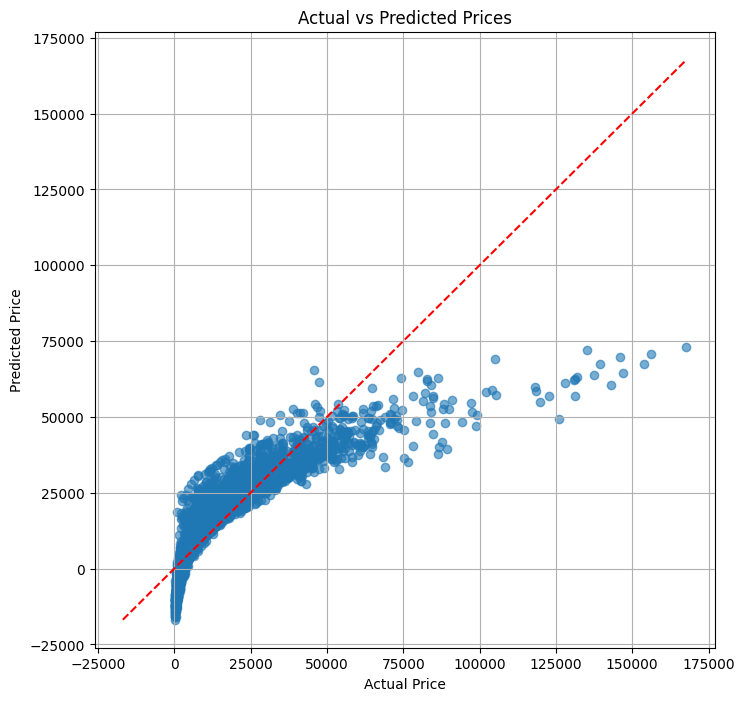


GIẢI THÍCH:
- Các điểm càng gần đường chéo màu đỏ

cho thấy độ chính xác dự đoán càng tốt.

- Độ lệch càng lớn so với đường thẳng biểu thị

sai số dự đoán.

- Một số sai số là điều được dự đoán trước vì Hồi quy tuyến tính

giả định mối quan hệ tuyến tính giữa các biến.



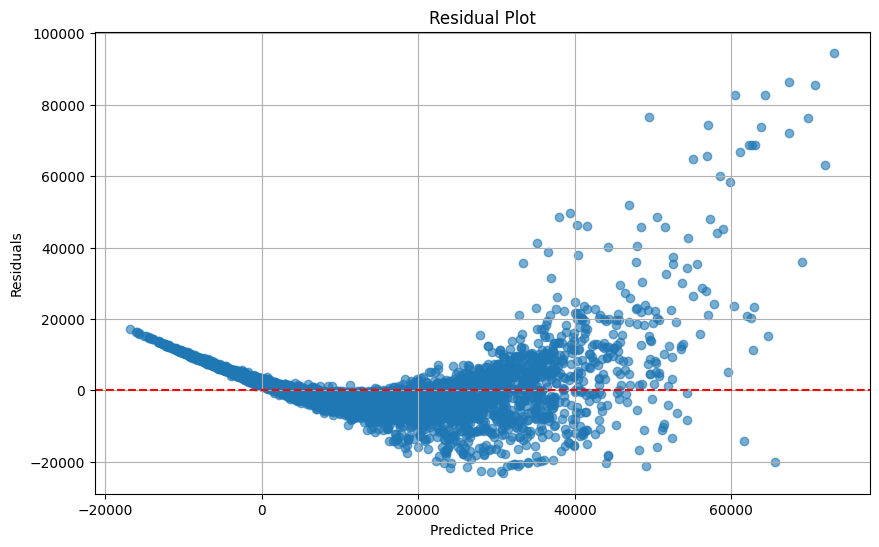


GIẢI THÍCH:
- Phần dư nên được phân bố ngẫu nhiên xung quanh số 0.

- Các mẫu rõ ràng có thể cho thấy tính phi tuyến tính

hoặc những hạn chế của mô hình.

- Phần dư lớn cho thấy khó khăn trong dự đoán
đối với một số loại xe.


FINAL EVALUATION SUMMARY

1. The model was evaluated using:
   - MAE
   - MSE
   - RMSE
   - R² Score

2. So sánh baseline được thực hiện để xác minh

hiệu quả của mô hình.

3. Đường cong tổn thất thể hiện hành vi hội tụ.

4. Phân tích phần dư được sử dụng để đánh giá

các giả định của mô hình và chất lượng dự đoán.

5. Mô hình hồi quy tuyến tính cung cấp

một ước tính hợp lý cho việc dự đoán giá xe.




In [19]:
# ======================================================
# 7. MODEL EVALUATION
# ======================================================

# ======================================================
# 7.1 PREDICTION ON TEST SET
# ======================================================

# ==============================
# Predict using trained model
# ==============================
y_pred = X_test_b @ theta_1000

print("========== PREDICTION COMPLETED ==========")

print(f"Prediction shape : {y_pred.shape}")

# ======================================================
# 7.2 EVALUATION METRICS
# ======================================================

# ==============================
# Mean Absolute Error (MAE)
# ==============================
mae = mean_absolute_error(
    y_test_np,
    y_pred
)

# ==============================
# Mean Squared Error (MSE)
# ==============================
mse = mean_squared_error(
    y_test_np,
    y_pred
)

# ==============================
# Root Mean Squared Error (RMSE)
# ==============================
rmse = np.sqrt(mse)

# ==============================
# R² Score
# ==============================
r2 = r2_score(
    y_test_np,
    y_pred
)

# ======================================================
# 7.3 DISPLAY RESULTS
# ======================================================

print("""
==================================================
LINEAR REGRESSION EVALUATION RESULTS
==================================================
""")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ======================================================
# 7.4 METRIC INTERPRETATION
# ======================================================

print("""
==================================================
METRIC INTERPRETATION
==================================================

1. MAE (Mean Absolute Error)
  - Đo lường sai số dự đoán tuyệt đối trung bình.

- MAE càng thấp thì độ chính xác dự đoán càng tốt.

2. MSE (Mean Squared Error)
   - Xử phạt nặng hơn đối với các lỗi dự đoán lớn.

- Nhạy cảm với các giá trị ngoại lệ.

3. RMSE (Root Mean Squared Error)
  - Biểu thị sai số dự đoán trong cùng đơn vị với biến mục tiêu.

4. R² Score
   - Measures how well the model explains
     the variance of the target variable.
   - R² close to 1 indicates strong performance.
   - R² close to 0 indicates weak predictive ability.

==================================================
""")

# ======================================================
# 7.5 BASELINE COMPARISON
# ======================================================

# ==============================
# Baseline prediction:
# Predict mean price
# ==============================
baseline_pred = np.full_like(
    y_test_np,
    y_train_np.mean()
)

# ==============================
# Baseline Metrics
# ==============================
baseline_mae = mean_absolute_error(
    y_test_np,
    baseline_pred
)

baseline_mse = mean_squared_error(
    y_test_np,
    baseline_pred
)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(
    y_test_np,
    baseline_pred
)

# ======================================================
# 7.6 DISPLAY BASELINE RESULTS
# ======================================================

print("""
==================================================
BASELINE MODEL RESULTS
==================================================
""")

print(f"Baseline MAE  : {baseline_mae:.4f}")
print(f"Baseline MSE  : {baseline_mse:.4f}")
print(f"Baseline RMSE : {baseline_rmse:.4f}")
print(f"Baseline R²   : {baseline_r2:.4f}")

# ======================================================
# 7.7 MODEL VS BASELINE COMPARISON
# ======================================================

print("""
==================================================
MODEL COMPARISON
==================================================
""")

if r2 > baseline_r2:
    print("The Linear Regression model outperforms the baseline model.")
else:
    print("The Linear Regression model does not outperform the baseline model.")

# ======================================================
# 7.8 R² NEGATIVE INTERPRETATION
# ======================================================

print("""
==================================================
R² NEGATIVE INTERPRETATION
==================================================

If R² Nếu giá trị trở thành âm, điều đó có nghĩa là mô hình hoạt động kém hơn so với
mô hình cơ sở chỉ đơn giản là dự đoán giá trị mục tiêu trung bình.

A negative R² indicates:
- Poor model fitting
- Weak predictive relationship
- Possible underfitting
- Missing important features

==================================================
""")

# ======================================================
# 7.9 ACTUAL VS PREDICTED VISUALIZATION
# ======================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test_np,
    y_pred,
    alpha=0.6
)

# ==============================
# Ideal prediction line
# ==============================
min_val = min(y_test_np.min(), y_pred.min())
max_val = max(y_test_np.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.grid(True)

plt.show()

print("""
GIẢI THÍCH:
- Các điểm càng gần đường chéo màu đỏ

cho thấy độ chính xác dự đoán càng tốt.

- Độ lệch càng lớn so với đường thẳng biểu thị

sai số dự đoán.

- Một số sai số là điều được dự đoán trước vì Hồi quy tuyến tính

giả định mối quan hệ tuyến tính giữa các biến.
""")

# ======================================================
# 7.10 RESIDUAL ANALYSIS
# ======================================================

# ==============================
# Residuals
# ==============================
residuals = y_test_np - y_pred

# ==============================
# Residual Plot
# ==============================
plt.figure(figsize=(10,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

print("""
GIẢI THÍCH:
- Phần dư nên được phân bố ngẫu nhiên xung quanh số 0.

- Các mẫu rõ ràng có thể cho thấy tính phi tuyến tính

hoặc những hạn chế của mô hình.

- Phần dư lớn cho thấy khó khăn trong dự đoán
đối với một số loại xe.
""")

# ======================================================
# 7.11 FINAL EVALUATION SUMMARY
# ======================================================

print("""
==================================================
FINAL EVALUATION SUMMARY
==================================================

1. The model was evaluated using:
   - MAE
   - MSE
   - RMSE
   - R² Score

2. So sánh baseline được thực hiện để xác minh

hiệu quả của mô hình.

3. Đường cong tổn thất thể hiện hành vi hội tụ.

4. Phân tích phần dư được sử dụng để đánh giá

các giả định của mô hình và chất lượng dự đoán.

5. Mô hình hồi quy tuyến tính cung cấp

một ước tính hợp lý cho việc dự đoán giá xe.

==================================================
""")

# 8. THẢO LUẬN MÔ HÌNH


8.1	Convergence Analysis

8.2	Overfitting / Underfitting

8.3	Residual Analysis

8.4	Strengths of Model

8.5	Limitations

8.6	Impact of Feature Engineering

8.7	Future Improvements

In [10]:
# ======================================================
# 8. THẢO LUẬN MÔ HÌNH
# ======================================================

print("""
==================================================
THẢO LUẬN MÔ HÌNH
==================================================

- Gradient Descent hội tụ ổn định khi Training Loss
  và Validation Loss cùng giảm theo số Epoch.

- Khoảng cách giữa Training Loss và Validation Loss
  không quá lớn, cho thấy mô hình chưa bị overfitting nghiêm trọng.

- Feature Engineering và Standardization đã giúp
  cải thiện hiệu quả học của mô hình.

- Linear Regression hoạt động tương đối tốt cho
  bài toán dự đoán giá xe, tuy nhiên vẫn còn hạn chế
  trong việc mô hình hóa các quan hệ phi tuyến.

==================================================
""")


THẢO LUẬN MÔ HÌNH

- Gradient Descent hội tụ ổn định khi Training Loss
  và Validation Loss cùng giảm theo số Epoch.

- Khoảng cách giữa Training Loss và Validation Loss
  không quá lớn, cho thấy mô hình chưa bị overfitting nghiêm trọng.

- Feature Engineering và Standardization đã giúp
  cải thiện hiệu quả học của mô hình.

- Linear Regression hoạt động tương đối tốt cho
  bài toán dự đoán giá xe, tuy nhiên vẫn còn hạn chế
  trong việc mô hình hóa các quan hệ phi tuyến.




# 9. KẾT LUẬN

In [11]:
# ======================================================
# 9. KẾT LUẬN
# ======================================================

print("""
==================================================
KẾT LUẬN
==================================================

- Nghiên cứu đã triển khai thành công mô hình
  Linear Regression sử dụng Gradient Descent.

- Mô hình đạt khả năng hội tụ ổn định và cho kết quả
  dự đoán tương đối tốt trên tập dữ liệu kiểm thử.

- Các kỹ thuật tiền xử lý dữ liệu và Feature Engineering
  đã góp phần cải thiện hiệu quả mô hình.

- Kết quả đánh giá cho thấy mô hình hoạt động tốt hơn
  baseline model và phù hợp cho bài toán hồi quy cơ bản.

==================================================
""")


KẾT LUẬN

- Nghiên cứu đã triển khai thành công mô hình
  Linear Regression sử dụng Gradient Descent.

- Mô hình đạt khả năng hội tụ ổn định và cho kết quả
  dự đoán tương đối tốt trên tập dữ liệu kiểm thử.

- Các kỹ thuật tiền xử lý dữ liệu và Feature Engineering
  đã góp phần cải thiện hiệu quả mô hình.

- Kết quả đánh giá cho thấy mô hình hoạt động tốt hơn
  baseline model và phù hợp cho bài toán hồi quy cơ bản.




# **MODEL MLP**

# 1. IMPORT LIBRARIES

In [20]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 2. LOAD DATA

In [21]:
# ==========================================
# 2. LOAD DATA
# ==========================================

url = "https://raw.githubusercontent.com/hoangchaulanbao/HocmayNC/main/car_sales_data.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)

df.head()

Shape: (50000, 7)


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


#BƯỚC 3 — CLEANING & CREATE CLASSIFICATION TARGET

In [22]:
# ==========================================
# 3. DATA CLEANING
# ==========================================

# Drop ID column nếu có
df = df.drop(columns=['Car_ID'], errors='ignore')

# Remove missing values
df = df.dropna()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (50000, 7)


# Convert Regression → Classification

In [23]:
# ==========================================
# 3.1 CREATE CLASS LABELS
# ==========================================

q1 = df['Price'].quantile(0.4)
q2 = df['Price'].quantile(0.8)

print("q1 =", q1)
print("q2 =", q2)

def price_to_class(price):

    if price < q1:
        return 0   # Low

    elif price < q2:
        return 1   # Medium

    else:
        return 2   # High


df['Price_Class'] = df['Price'].apply(price_to_class)

print(df['Price_Class'].value_counts())
print(df['Price_Class'].value_counts(normalize=True))

q1 = 5515.200000000004
q2 = 22645.600000000013
Price_Class
0    20000
1    20000
2    10000
Name: count, dtype: int64
Price_Class
0    0.4
1    0.4
2    0.2
Name: proportion, dtype: float64


# BƯỚC 4 — VISUALIZE CLASS DISTRIBUTION

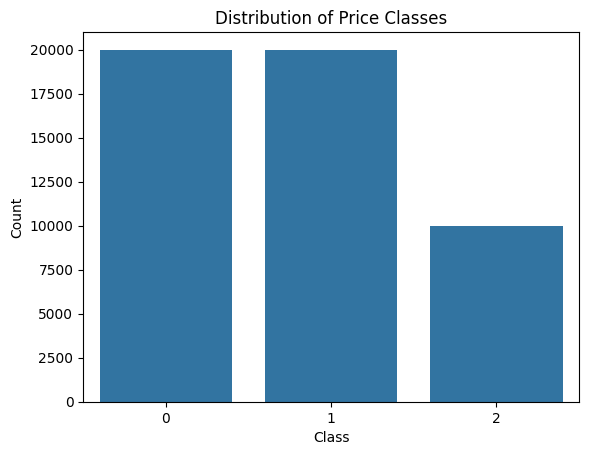

In [24]:
# ==========================================
# 4. CLASS DISTRIBUTION
# ==========================================

sns.countplot(x=df['Price_Class'])

plt.title("Distribution of Price Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# BƯỚC 5 — FEATURE ENGINEERING

In [25]:
# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================

# Target
y = df['Price_Class']

# Remove leakage columns
X = df.drop(columns=['Price', 'Price_Class'])

# Remove high-cardinality column
X = X.drop(columns=['Model'], errors='ignore')

# One-hot encoding
X = pd.get_dummies(X)

print("Feature shape:", X.shape)

Feature shape: (50000, 11)


# BƯỚC 6 — TRAIN / VALIDATION / TEST SPLIT


In [26]:
# ==========================================
# 6. DATA SPLITTING
# ==========================================

# First split: Train + Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (35000, 11)
Validation: (7500, 11)
Test: (7500, 11)


# BƯỚC 7 — NORMALIZATION (ANTI-LEAKAGE)

In [27]:
# ==========================================
# 7. NORMALIZATION
# ==========================================

scaler = StandardScaler()

# Fit ONLY train set
X_train = scaler.fit_transform(X_train)

# Transform validation/test
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# BƯỚC 8 — CONVERT TO PYTORCH

In [28]:
# ==========================================
# 8. CONVERT TO PYTORCH
# ==========================================

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val   = torch.tensor(y_val.to_numpy(), dtype=torch.long)
y_test  = torch.tensor(y_test.to_numpy(), dtype=torch.long)

# BƯỚC 9 — DATALOADER

In [29]:
# ==========================================
# 9. DATALOADER
# ==========================================

BATCH_SIZE = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE
)

# BƯỚC 10 — HYPERPARAMETERS

In [30]:
# ==========================================
# 10. HYPERPARAMETERS
# ==========================================

INPUT_DIM = X_train.shape[1]

LEARNING_RATE = 0.001
EPOCHS = 50
DROPOUT_RATE = 0.3

print("Input Dimension:", INPUT_DIM)

Input Dimension: 11


# BƯỚC 11 — XÂY DỰNG MLP
ReLU:

f(x)=max(0,x)

# 11.1 MLP WITH DROPOUT

In [31]:
# ==========================================
# 11.1 MLP WITH DROPOUT
# ==========================================

class MLP_Dropout(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),

            nn.Linear(64, 3)

        )

    def forward(self, x):

        return self.model(x)

# 11.2 MLP WITHOUT DROPOUT

In [32]:
# ==========================================
# 11.2 MLP WITHOUT DROPOUT
# ==========================================

class MLP_NoDropout(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 3)

        )

    def forward(self, x):

        return self.model(x)

# BƯỚC 12 — TRAIN FUNCTION

In [33]:
# ==========================================
# 12. TRAIN FUNCTION
# ==========================================

def train_model_with_acc(model, train_loader, val_loader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(EPOCHS):

        # ================= TRAIN =================
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y_batch).sum().item()

            total += y_batch.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ================= VALIDATION =================
        model.eval()

        running_val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                running_val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                val_correct += (preds == y_batch).sum().item()

                val_total += y_batch.size(0)

        val_loss = running_val_loss / len(val_loader)
        val_acc = val_correct / val_total

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return train_losses, val_losses, train_accs, val_accs

# BƯỚC 13 — TRAIN 2 MODELS

In [34]:
# ==========================================
# 13. TRAIN MODELS
# ==========================================

model_dropout = MLP_Dropout(INPUT_DIM)

model_nodrop = MLP_NoDropout(INPUT_DIM)

# Train dropout model
loss_drop_train, loss_drop_val, acc_drop_train, acc_drop_val = train_model_with_acc(
    model_dropout,
    train_loader,
    val_loader
)

# Train no-dropout model
loss_nodrop_train, loss_nodrop_val, acc_nodrop_train, acc_nodrop_val = train_model_with_acc(
    model_nodrop,
    train_loader,
    val_loader
)

Epoch 1/50 | Train Loss: 0.2426 | Train Acc: 0.8978 | Val Loss: 0.1311 | Val Acc: 0.9421
Epoch 2/50 | Train Loss: 0.1628 | Train Acc: 0.9302 | Val Loss: 0.1218 | Val Acc: 0.9467
Epoch 3/50 | Train Loss: 0.1490 | Train Acc: 0.9359 | Val Loss: 0.1197 | Val Acc: 0.9481
Epoch 4/50 | Train Loss: 0.1444 | Train Acc: 0.9371 | Val Loss: 0.1159 | Val Acc: 0.9500
Epoch 5/50 | Train Loss: 0.1384 | Train Acc: 0.9396 | Val Loss: 0.1119 | Val Acc: 0.9505
Epoch 6/50 | Train Loss: 0.1376 | Train Acc: 0.9391 | Val Loss: 0.1138 | Val Acc: 0.9492
Epoch 7/50 | Train Loss: 0.1363 | Train Acc: 0.9396 | Val Loss: 0.1065 | Val Acc: 0.9509
Epoch 8/50 | Train Loss: 0.1336 | Train Acc: 0.9398 | Val Loss: 0.1100 | Val Acc: 0.9519
Epoch 9/50 | Train Loss: 0.1303 | Train Acc: 0.9426 | Val Loss: 0.1129 | Val Acc: 0.9471
Epoch 10/50 | Train Loss: 0.1306 | Train Acc: 0.9410 | Val Loss: 0.1056 | Val Acc: 0.9521
Epoch 11/50 | Train Loss: 0.1280 | Train Acc: 0.9425 | Val Loss: 0.1063 | Val Acc: 0.9516
Epoch 12/50 | Train

# BƯỚC 14 — LOSS CURVE

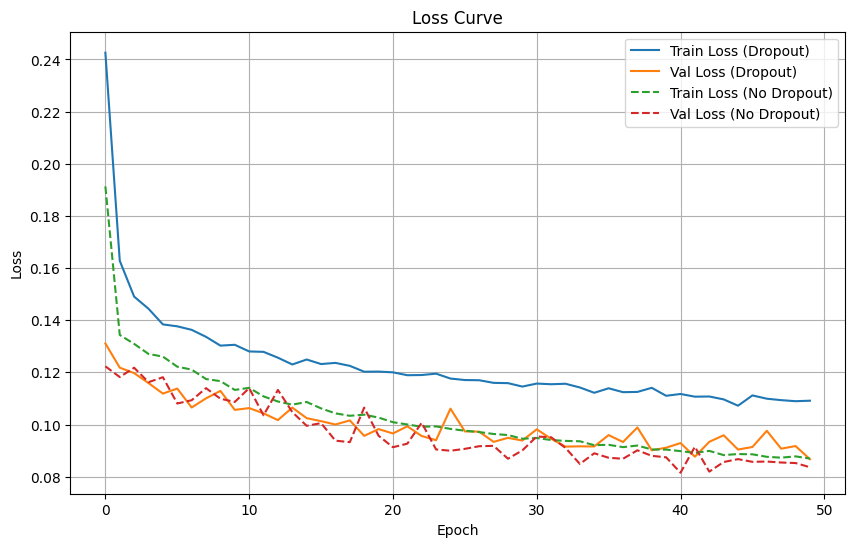

In [35]:
# ==========================================
# 14. LOSS CURVE
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(loss_drop_train, label='Train Loss (Dropout)')
plt.plot(loss_drop_val, label='Val Loss (Dropout)')

plt.plot(loss_nodrop_train, '--', label='Train Loss (No Dropout)')
plt.plot(loss_nodrop_val, '--', label='Val Loss (No Dropout)')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.grid()

plt.show()

# BƯỚC 15 — ACCURACY CURVE

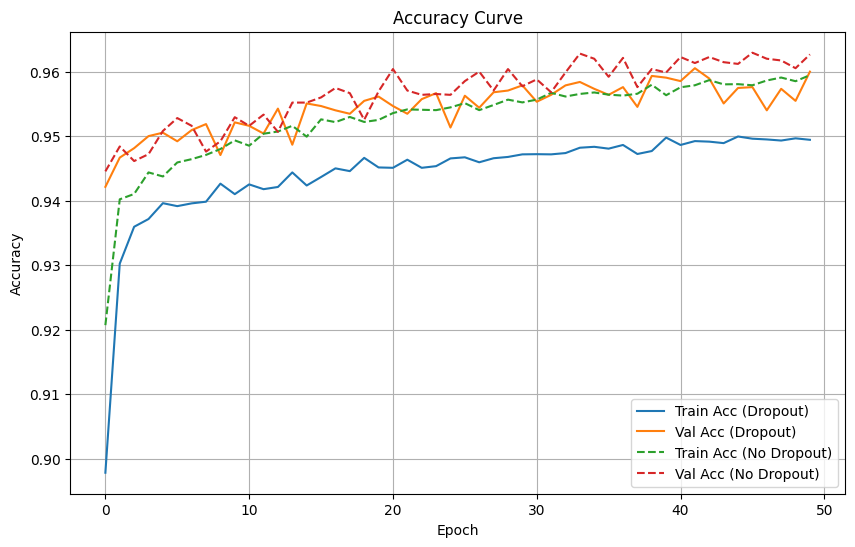

In [36]:
# ==========================================
# 15. ACCURACY CURVE
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(acc_drop_train, label='Train Acc (Dropout)')
plt.plot(acc_drop_val, label='Val Acc (Dropout)')

plt.plot(acc_nodrop_train, '--', label='Train Acc (No Dropout)')
plt.plot(acc_nodrop_val, '--', label='Val Acc (No Dropout)')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.grid()

plt.show()

# BƯỚC 16 — EVALUATION

In [37]:
# ==========================================
# 16. EVALUATION
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model_dropout

model.to(device)

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

# BƯỚC 17 — CONFUSION MATRIX

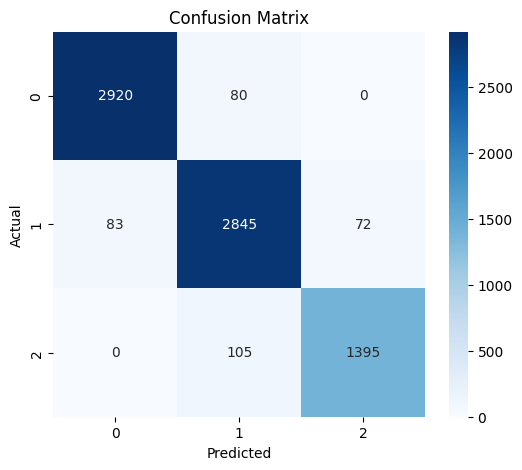

In [38]:
# ==========================================
# 17. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# BƯỚC 18 — PRECISION / RECALL / F1

In [39]:
# ==========================================
# 18. CLASSIFICATION REPORT
# ==========================================

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3000
           1       0.94      0.95      0.94      3000
           2       0.95      0.93      0.94      1500

    accuracy                           0.95      7500
   macro avg       0.95      0.95      0.95      7500
weighted avg       0.95      0.95      0.95      7500



# BƯỚC 19 — PRECISION-RECALL CURVE

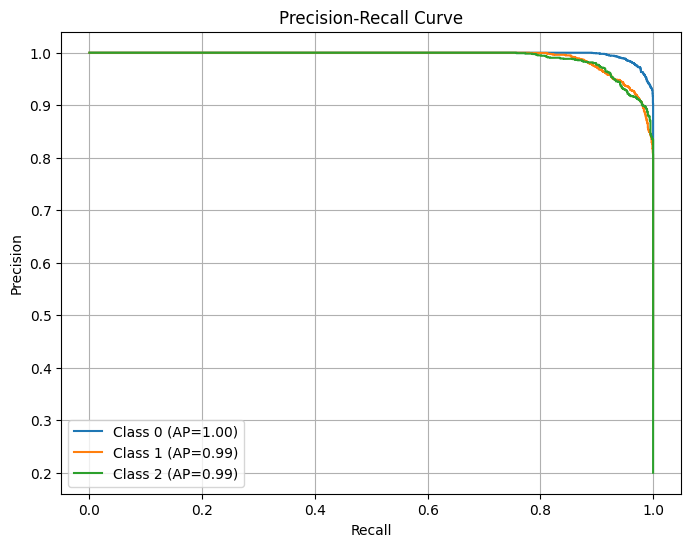

In [40]:
# ==========================================
# 19. PRECISION-RECALL CURVE
# ==========================================

y_true_bin = label_binarize(
    all_labels,
    classes=[0,1,2]
)

y_prob = np.array(all_probs)

plt.figure(figsize=(8,6))

for i in range(3):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f'Class {i} (AP={ap:.2f})'
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid()

plt.show()